In [9]:
# моделирование колебаний
# двухатомной молекулы
# в квазиклассическом приближении

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение функции solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

In [ ]:
# Ячейка № 2

# задание функции, возвращающей значения
# потенциала Леннарда-Джонсона
def F(r, E):
    return E - 4 * (1 / r**12 - 1 / r**6)


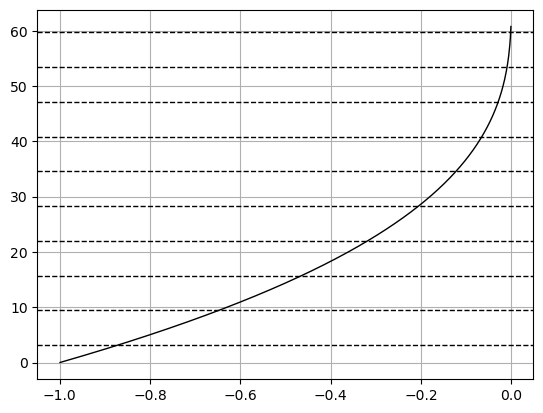

In [ ]:
# Ячейка № 3

# вычисление и визуализация
# значений зависимости безразмерного действия
# от энергии колебаний двухатомной молекулы и
# и разрешенных, в соответствие
# с квазиклассическим приближением,
# значений действия

# задание минимального
# значения энергии
E_min = -1 + 10**-3

# задание максимального
# значения энергии
E_max = -(10**-3)

# задание значения
# переменной Gamma в (16.32)
Gamma = 80

# задание числа узлов сетки по энергии
N_E = 800

# вычисление координат сетки по энергии
E = np.linspace(E_min, E_max, N_E)

# задание числа узлов координатной сетки
N_R = 10**3


# инициализация массива Z размерности N_E*4,
# используемого для хранения
# координат правой и левой точек поворота частицы,
# разрешенного значения энергии и
# соответствующего значения действия
Z = np.zeros([N_E, 4])

for i in range(N_E):
    # вычисление координат левой  и
    # правой точек остановки частицы
    # для данного значения энергии
    # в соответствие с (16.34)
    x = (1 + np.sqrt(1 + E[i])) / 2
    R_Left = 1 / x ** (1 / 6)

    x = (1 - np.sqrt(1 + E[i])) / 2
    R_Right = 1 / x ** (1 / 6)

    # вычисление значений координатной сетки,
    # используемой для численного вычисления
    # интеграла в (16.30)
    R = np.linspace(R_Left, R_Right, N_R)

    # вычисление значения подкоренного выражения
    # в (16.30)
    S = F(R, E[i])

    # проверка на наличие
    # отрицательных значений
    # подкоренного выражения в (16.32) и,
    # при обнаружении таковых, их обнуление
    for k in range(N_R):
        if S[k] < 0:
            S[k] = 0

    # вычисление численного значения
    # интеграла в (16.30)
    I = Gamma * np.trapz(np.sqrt(S), R)

    # размещение в массиве Z:
    # координат левой и правой точек остановки,
    # текущего значения энергии и
    # соответствующего значения действия
    Z[i, 0] = R_Left
    Z[i, 1] = R_Right
    Z[i, 2] = E[i]
    Z[i, 3] = I

# визуализация зависимости действия
# от энергии колебаний
plt.plot(Z[:, 2], Z[:, 3], "-k", lw=1)
plt.grid(True)

# вычисление числа разрешенных
# значений энергии (N_L+1) колебаний,
# находящихся в выбранном интервале
# изменения значений энергии колебаний
N_L = int(Z[N_E - 1, 3] / (2 * np.pi) - 0.5)

# инициализация массива,
# используемого для
# хранения разрешенных значений действия
S_L = np.zeros(N_L + 1)

# вычисление и визуализация
# разрешенных значений действия
for i in range(N_L + 1):
    S_L[i] = 2 * np.pi * (i + 0.5)
    plt.axhline(S_L[i], color="black", linestyle="--", linewidth=1)

plt.show()

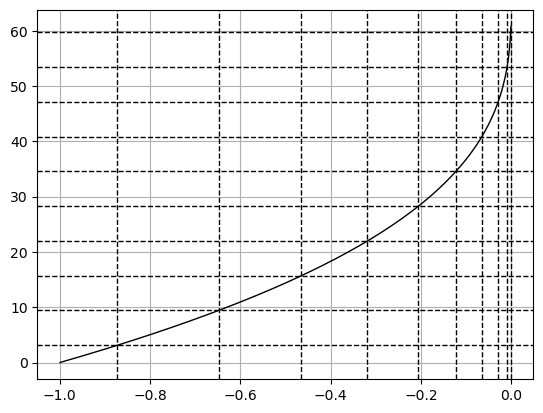

E[ 1 ]=  [ 1.06660553  1.20861223 -0.87194138] 

E[ 2 ]=  [ 1.03861866  1.30403677 -0.64815839] 

E[ 3 ]=  [ 1.02428339  1.39778667 -0.46483667] 

E[ 4 ]=  [ 1.01531571  1.50179801 -0.31861551] 

E[ 5 ]=  [ 1.00937036  1.62443507 -0.2059109 ] 

E[ 6 ]=  [ 1.00535463  1.77911151 -0.12289503] 

E[ 7 ]=  [ 1.00276761  1.98300255 -0.06547207] 

E[ 8 ]=  [ 1.00120024  2.27719757 -0.02926783] 

E[ 9 ]=  [ 1.00035513  2.78826438 -0.00961804] 

E[ 10 ]=  [ 1.00004168e+00  3.98405412e+00 -1.66599383e-03] 



In [12]:
# Ячейка № 4

# вычисление значений энергии,
# соответствующих разрешенным
# действия значениям, из визуализация
# и отображение на экране
j = 0
n = 0

# инициализация массива
# с размерностью N_L*3,
# используемого для хранения левой
# и правой точек остановки, а также
# разрешенного значения энергии
E_L = np.zeros([N_L + 1, 3])
for i in range(N_E):
    if Z[i, 3] == S_L[n]:
        E_L[n, 0] = Z[i, 0]
        E_L[n, 1] = Z[i, 1]
        E_L[n, 2] = Z[i, 2]
        n = n + 1
    else:
        if Z[i, 3] > S_L[n]:
            x1 = Z[i - 1, 2]
            x2 = Z[i, 2]
            y1 = Z[i - 1, 3]
            y2 = Z[i, 3]
            a = (y2 - y1) / (x2 - x1)
            b = y1 - a * x1
            E_L[n, 0] = Z[i, 0]
            E_L[n, 1] = Z[i, 1]
            E_L[n, 2] = (2 * np.pi * (n + 0.5) - b) / a
            n = n + 1

# визуализация зависимости
# действия от энергии колебаний
plt.plot(Z[:, 2], Z[:, 3], "-k", lw=1)
plt.grid(True)

# визуализация разрешенных
# значений уровней действия и
# соответствующих значений
# энергии колебаний
for i in range(N_L + 1):
    S_L[i] = 2 * np.pi * (i + 0.5)
    plt.axhline(S_L[i], color="black", linestyle="--", linewidth=1)
    plt.axvline(E_L[i, 2], color="black", linestyle="--", linewidth=1)

plt.show()

# вывод на экран значений
# энергии колебаний, соответствующих
# разрешенному значению действия
for i in range(len(E_L)):
    print("E[", i + 1, "]= ", E_L[i], "\n")

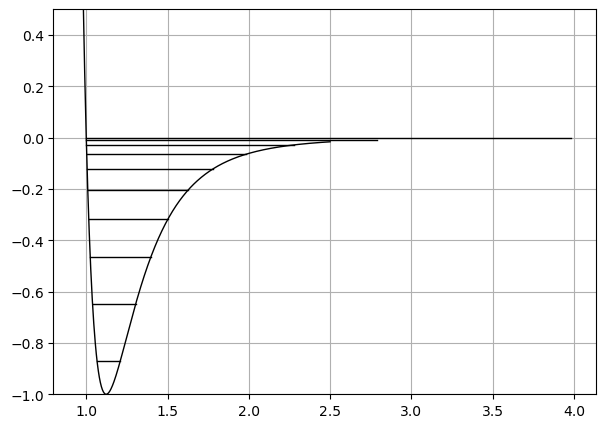

In [13]:
# Ячейка № 5

# визуализация потенциала и
# разрешенных значений
# энергии колебаний

R_min = 0.95
R_max = 2.5
Np = 500
R = np.linspace(R_min, R_max, Np)
U = -F(R, 0)

fig = plt.figure(figsize=(7, 5))

plt.plot(R, U, "-k", lw=1)

for i in range(N_L + 1):
    R = np.linspace(E_L[i, 0], E_L[i, 1], N_R)
    plt.plot([E_L[i, 0], E_L[i, 1]], [E_L[i, 2], E_L[i, 2]], "-k", lw=1)
    plt.ylim(-1, 0.5)
plt.grid(True)

plt.show()

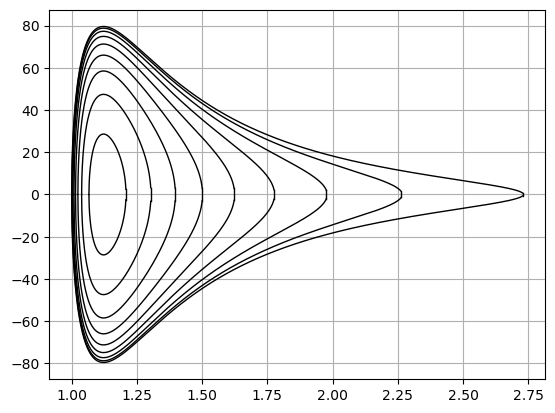

In [14]:
# Ячейка № 6

# вычисление значений координат
# фазовой траектории колебаний
# и ее визуализация

# задание функции, возвращающей
# значение безразмерного
# волнового числа де Бройля
def P(r, E):
    Tmp = F(r, E)
    Tmp[0] = 0
    n = 1
    while Tmp[n] >= 0:
        n = n + 1
    # отбрасывание отрицательных
    # значений подкоренного
    # выражения в (16.32)
    F_R = np.zeros([n - 2, 2])
    F_R[0 : n - 2, 0] = r[0 : n - 2]
    F_R[0 : n - 2, 1] = Gamma * np.sqrt(Tmp[0 : n - 2])

    return F_R


# визуализация фазовых траекторий колебаний,
# вычисленных для разрешенных уровней энергии
for i in range(N_L):
    R = np.linspace(E_L[i, 0], E_L[i, 1], N_R)
    P_R = P(R, E_L[i, 2])
    plt.plot(P_R[:, 0], P_R[:, 1], "-k", lw=1)
    plt.plot(
        [P_R[len(P_R) - 1, 0], P_R[len(P_R) - 1, 0]],
        [P_R[len(P_R) - 1, 1], -P_R[len(P_R) - 1, 1]],
        "-k",
        lw=1,
    )
    plt.plot(P_R[:, 0], -P_R[:, 1], "-k", lw=1)
    plt.grid(True)

plt.show()

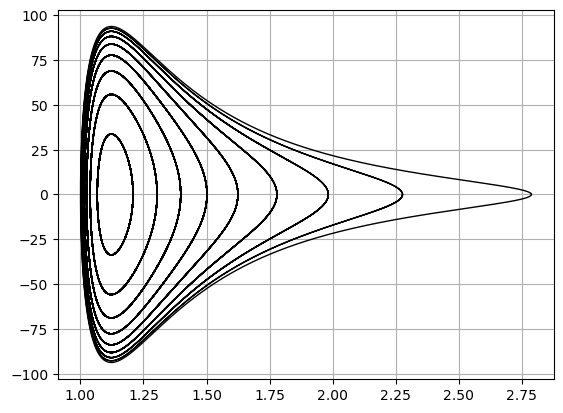

In [ ]:
# Ячейка № 7

# визуализация фазовой
# траектории колебаний
# на основе численного решения
# уравнения движения частицы в
# потенциале Леннарда-Джонсона

# задание функции, возвращающей
# значение силы, действующей
# на частицу
def Acc(t, z):
    dy = np.zeros(2)
    dy[0] = z[1]
    dy[1] = 2 ** (7 / 3) * np.pi**2 / 3 * (2 / z[0] ** 13 - 1 / z[0] ** 7)

    return dy


# задание значения правой границы
# временного интервала, на котором
# выполняется поиск численного решения
# уравнения движения
T_fin = 22

# задание числа узлов временной сетки
Np = 5 * 10**4

# задание шага временной сетки
dt = T_fin / Np

for i in range(N_L):
    # вызов функции, возвращающей
    # численное решение системы ОДУ (10.8)
    # c начальными условиями, соответствующими
    # разрешенным значениям энергии
    Solv = solve_ivp(Acc, [0, T_fin], [E_L[i, 1], 0], max_step=dt)

    # размещение значений координат узлов
    # временной сетки, на которой найдены чиcленные решения
    # системы ОДУ (6.17), в массиве t
    t = Solv.t

    # размещение мгновенных значений
    # координаты колебаний в массиве х
    x = Solv.y[0, :]

    # размещение мгновенных значений
    # скорости колебаний в массиве vx
    vx = Solv.y[1, :]

    # визуализация фазовой
    # траектории колебаний,
    # соответствующей i-ому значению
    # разрешенной энергии
    plt.plot(x, Gamma * vx, "-k", lw=1)

plt.grid(True)

plt.show()

i =  1 j =  0
x = 1.0666686991127763583598437692359294299460846399816248720112531035281911642893227
Negative -2.4E-79
i =  4 j =  0
x = 1.0153355812864810783194875032805408816500061357910510462462055269347929011478347
Negative -6.4E-79
i =  6 j =  999
x = 1.7772709803032507411735942705188822791789408264673478941386472074828500829076339
Negative -1E-80
i =  7 j =  999
x = 1.9790299677851888883388664223411309780331637458671796124397561665696419244471795
Negative -8E-81
i =  8 j =  0
x = 1.0012338599281008291859413593977962252847937854195856568990783223157598882917837
Negative -9.6E-79
i =  8 j =  999
x = 2.2667800369705246294012145318814573017875663097966120161082227356951198223310032
Negative -3E-81
i =  9 j =  0
x = 1.0004022855592400742689100152051975816867026106471597848058585323923795941917203
Negative -2.4E-79


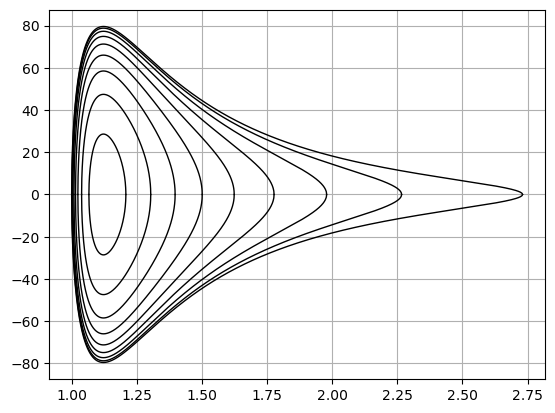

In [ ]:
# Ячейка № 8

# подключение библиотеки
# для работы с корректно округляемыми
# числами с плавающей запятой
from decimal import *

# задание значений точно вычисляем цифр после запятой
getcontext().prec = 80

# инициализация массивов, используемых
# для хранения значений безразмерного
# волнового числа волны де Бройля,
# координат узлов сетки,
# в которых вычисляются значения
# безразмерного волнового числа волны де Бройля и
# значения потенциала Леннарда-Джоносона с
# точностью до 300 знака после запятой

P_decimal = np.zeros(N_R, dtype=np.dtype(Decimal))
R_decimal = np.zeros(N_R, dtype=np.dtype(Decimal))
V_decimal = np.zeros(N_R, dtype=np.dtype(Decimal))

for i in range(N_L):
    # вычисление координаты
    # левой точки остановки
    # с точностью до 100-го знака после запятой
    E_decimal = Decimal(str(E_L[i, 2]))
    Q1_decimal = Decimal("1") + E_decimal
    Q2_decimal = (Decimal("1") + Q1_decimal.sqrt()) / Decimal("2")
    Q3_decimal = Decimal("-1") / Decimal("6") * Q2_decimal.ln()
    X1_decimal = Q3_decimal.exp()

    # вычисление координаты
    # правой точки остановки
    # с точностью до 80-го знака после запятой
    Q2_decimal = (Decimal("1") - Q1_decimal.sqrt()) / Decimal("2")
    Q3_decimal = Decimal("-1") / Decimal("6") * Q2_decimal.ln()
    X2_decimal = Q3_decimal.exp()

    # вычисление координат
    # узлов координатной сетки, в которых вычисляются
    # значения безрамерного волнового числа волны де Бройля и
    # значения потенциала Лейнарда-Джоносона с
    # точностью до 300-го знака после запятой
    dR_decimal = (X2_decimal - X1_decimal) / (N_R - 1)

    # вычисление  в узлах
    # координатной сетки значений безрамерного
    # волнового числа волны де Бройля
    # с точностью до 80-го знака после запятой
    for j in range(N_R):
        R_decimal[j] = X1_decimal + dR_decimal * j
        x1_decimal = Decimal("-12") * R_decimal[j].ln()
        x2_decimal = Decimal("-6") * R_decimal[j].ln()
        V_decimal[j] = 4 * (x1_decimal.exp() - x2_decimal.exp())
        P_demical_tmp = E_decimal - V_decimal[j]
        # проверка на наличие
        # отрицательных значений
        # подкоренного выражения в (16.32) и,
        # при обнаружении таковых, их обнуление
        if P_demical_tmp < 0:
            P_demical = Decimal("0")
        if P_demical_tmp < 0:
            print("i = ", i + 1, "j = ", j)
            print(f"x = {R_decimal[j]}")
            print(f"Negative {P_demical_tmp}")
            P_demical_tmp = Decimal("0")

        P_decimal[j] = P_demical_tmp.sqrt()
    # визуализация фазовых траекторий колебаний,
    # вычисленных для разрешенных уровней энергии
    plt.plot(R_decimal, Gamma * P_decimal, "-k", lw=1)
    plt.plot(R_decimal, -Gamma * P_decimal, "-k", lw=1)

plt.grid(True)
plt.show()
